In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# Load combined data
df = pd.read_csv('../data/processed/combined_stocks.csv', parse_dates=['Date'])
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f"✅ Data loaded! Shape: {df.shape}")
print(df.head())

✅ Data loaded! Shape: (5094, 9)
        Date        Open        High         Low       Close   Adj Close  \
0 2018-01-02  170.160004  172.300003  169.259995  172.259995  166.804016   
1 2018-01-03  172.529999  174.550003  171.960007  172.229996  166.774963   
2 2018-01-04  172.539993  173.470001  172.080002  173.029999  167.549622   
3 2018-01-05  173.440002  175.369995  173.050003  175.000000  169.457214   
4 2018-01-08  174.350006  175.610001  173.929993  174.350006  168.827820   

       Volume Ticker    Return  
0  25555900.0   AAPL  0.017905  
1  29517900.0   AAPL -0.000174  
2  22434600.0   AAPL  0.004645  
3  23660000.0   AAPL  0.011385  
4  20567800.0   AAPL -0.003714  


 Rolling Feature Engineering (Core Logic!)

In [7]:
def compute_features(group):
    group = group.copy().sort_values('Date').reset_index(drop=True)
    
    # --- Daily Return ---
    group['ret'] = group['Adj Close'].pct_change()
    
    # --- Return Z-Score (rolling 63 days, past only) ---
    roll_ret = group['ret'].shift(1).rolling(window=W_RETURN, min_periods=MIN_OBS)
    group['ret_mean'] = roll_ret.mean()
    group['ret_std']  = roll_ret.std()
    group['ret_z']    = (group['ret'] - group['ret_mean']) / group['ret_std']
    
    # --- Volume Z-Score (rolling 21 days, log volume) ---
    group['log_vol'] = np.log1p(group['Volume'])
    roll_vol = group['log_vol'].shift(1).rolling(window=W_VOLUME, min_periods=W_VOLUME)
    group['vol_mean'] = roll_vol.mean()
    group['vol_std']  = roll_vol.std()
    group['vol_z']    = (group['log_vol'] - group['vol_mean']) / group['vol_std']
    
    # --- Intraday Range Percentile (rolling 63 days) ---
    group['intraday_range'] = (group['High'] - group['Low']) / group['Close']
    
    def range_percentile(series):
        result = pd.Series(index=series.index, dtype=float)
        for i in range(len(series)):
            if i < W_RANGE:
                result.iloc[i] = np.nan
            else:
                past = series.iloc[i - W_RANGE:i].values
                current = series.iloc[i]
                result.iloc[i] = (past < current).sum() / len(past) * 100
        return result
    
    group['range_pct'] = range_percentile(group['intraday_range'])
    
    return group

print("⏳ Computing features for all tickers (takes ~1-2 mins)...")

# ✅ FIX: Use .reset_index() to preserve Ticker as a column
featured = df.groupby('Ticker', group_keys=True).apply(
    compute_features, include_groups=False
).reset_index(level=0, drop=False)

# ✅ Reset index cleanly
featured = featured.reset_index(drop=True)
featured = featured.dropna(subset=['ret_z', 'vol_z', 'range_pct']).reset_index(drop=True)

print(f"✅ Features computed! Shape: {featured.shape}")
print(featured[['Date', 'Ticker', 'ret', 'ret_z', 'vol_z', 'range_pct']].head(10))

⏳ Computing features for all tickers (takes ~1-2 mins)...
✅ Features computed! Shape: (4518, 19)
        Date Ticker       ret     ret_z     vol_z  range_pct
0 2018-04-05   AAPL  0.006934  0.403035 -0.884580  31.746032
1 2018-04-06   AAPL -0.025579 -1.531415  0.301676  73.015873
2 2018-04-09   AAPL  0.009918  0.590624 -0.611452  57.142857
3 2018-04-10   AAPL  0.018818  1.111291 -0.800237  34.920635
4 2018-04-11   AAPL -0.004675 -0.276423 -1.927034  30.158730
5 2018-04-12   AAPL  0.009859  0.566753 -1.605648  14.285714
6 2018-04-13   AAPL  0.003388  0.183587 -1.047989  15.873016
7 2018-04-16   AAPL  0.006238  0.349970 -1.632503   1.587302
8 2018-04-17   AAPL  0.013764  0.788587 -0.729699  33.333333
9 2018-04-18   AAPL -0.002244 -0.151762 -1.695782   9.523810


In [8]:
import warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None
print("✅ Warnings suppressed!")

✅ Warnings suppressed!


Apply Anomaly Thresholds (Rule-Based)

In [9]:
# Rule-based detector from project spec
def label_anomaly(row):
    flags = []
    anom = False
    
    if abs(row['ret_z']) > 2.5:
        anom = True
        if row['ret'] < 0:
            flags.append('crash')
        else:
            flags.append('spike')
    
    if row['vol_z'] > 2.5:
        anom = True
        flags.append('volume_shock')
    
    if row['range_pct'] > 95:
        anom = True
        flags.append('range_extreme')
    
    return pd.Series({
        'anomaly_flag': int(anom),
        'type': '+'.join(flags) if flags else 'normal'
    })

featured[['anomaly_flag', 'type']] = featured.apply(label_anomaly, axis=1)

total = len(featured)
anomalies = featured['anomaly_flag'].sum()
print(f"✅ Rule-based detection done!")
print(f"Total records : {total}")
print(f"Anomalies flagged: {anomalies} ({anomalies/total*100:.2f}%)")
print(f"\nAnomaly type breakdown:")
print(featured[featured['anomaly_flag']==1]['type'].value_counts())

✅ Rule-based detection done!
Total records : 4518
Anomalies flagged: 528 (11.69%)

Anomaly type breakdown:
type
range_extreme                       206
volume_shock                         77
crash+range_extreme                  60
spike+range_extreme                  40
volume_shock+range_extreme           36
spike                                28
crash+volume_shock+range_extreme     23
crash                                23
crash+volume_shock                   13
spike+volume_shock+range_extreme     12
spike+volume_shock                   10
Name: count, dtype: int64


Market-Level Features

In [10]:
# Aggregate across tickers per day
market = featured.groupby('Date').agg(
    market_ret   = ('ret', 'mean'),
    breadth      = ('ret', lambda x: (x > 0).sum() / len(x)),
    flag_rate    = ('anomaly_flag', 'mean'),
    n_tickers    = ('Ticker', 'count')
).reset_index()

# Market anomaly: market_ret z-score > 95th pct OR breadth < 0.3
roll_mkt = market['market_ret'].shift(1).rolling(window=63, min_periods=63)
market['mkt_ret_mean'] = roll_mkt.mean()
market['mkt_ret_std']  = roll_mkt.std()
market['mkt_ret_z']    = (market['market_ret'] - market['mkt_ret_mean']) / market['mkt_ret_std']

# Market anomaly flag
market['market_anomaly_flag'] = (
    (market['mkt_ret_z'].abs() > market['mkt_ret_z'].abs().quantile(0.95)) |
    (market['breadth'] < 0.3)
).astype(int)

print(f"✅ Market features computed!")
print(f"Market anomaly days: {market['market_anomaly_flag'].sum()}")
print(market[market['market_anomaly_flag']==1][['Date','market_ret','breadth','flag_rate']].tail(10))

✅ Market features computed!
Market anomaly days: 166
          Date  market_ret   breadth  flag_rate
485 2020-03-10    0.059104  1.000000   0.666667
486 2020-03-11   -0.040740  0.000000   0.111111
487 2020-03-12   -0.100293  0.000000   0.888889
488 2020-03-13    0.094920  0.888889   1.000000
489 2020-03-16   -0.136441  0.000000   1.000000
491 2020-03-18   -0.044258  0.111111   0.333333
493 2020-03-20   -0.025776  0.111111   0.333333
496 2020-03-25   -0.009509  0.111111   0.000000
498 2020-03-27   -0.034152  0.000000   0.000000
501 2020-04-01   -0.048261  0.000000   0.000000


Visualize Features

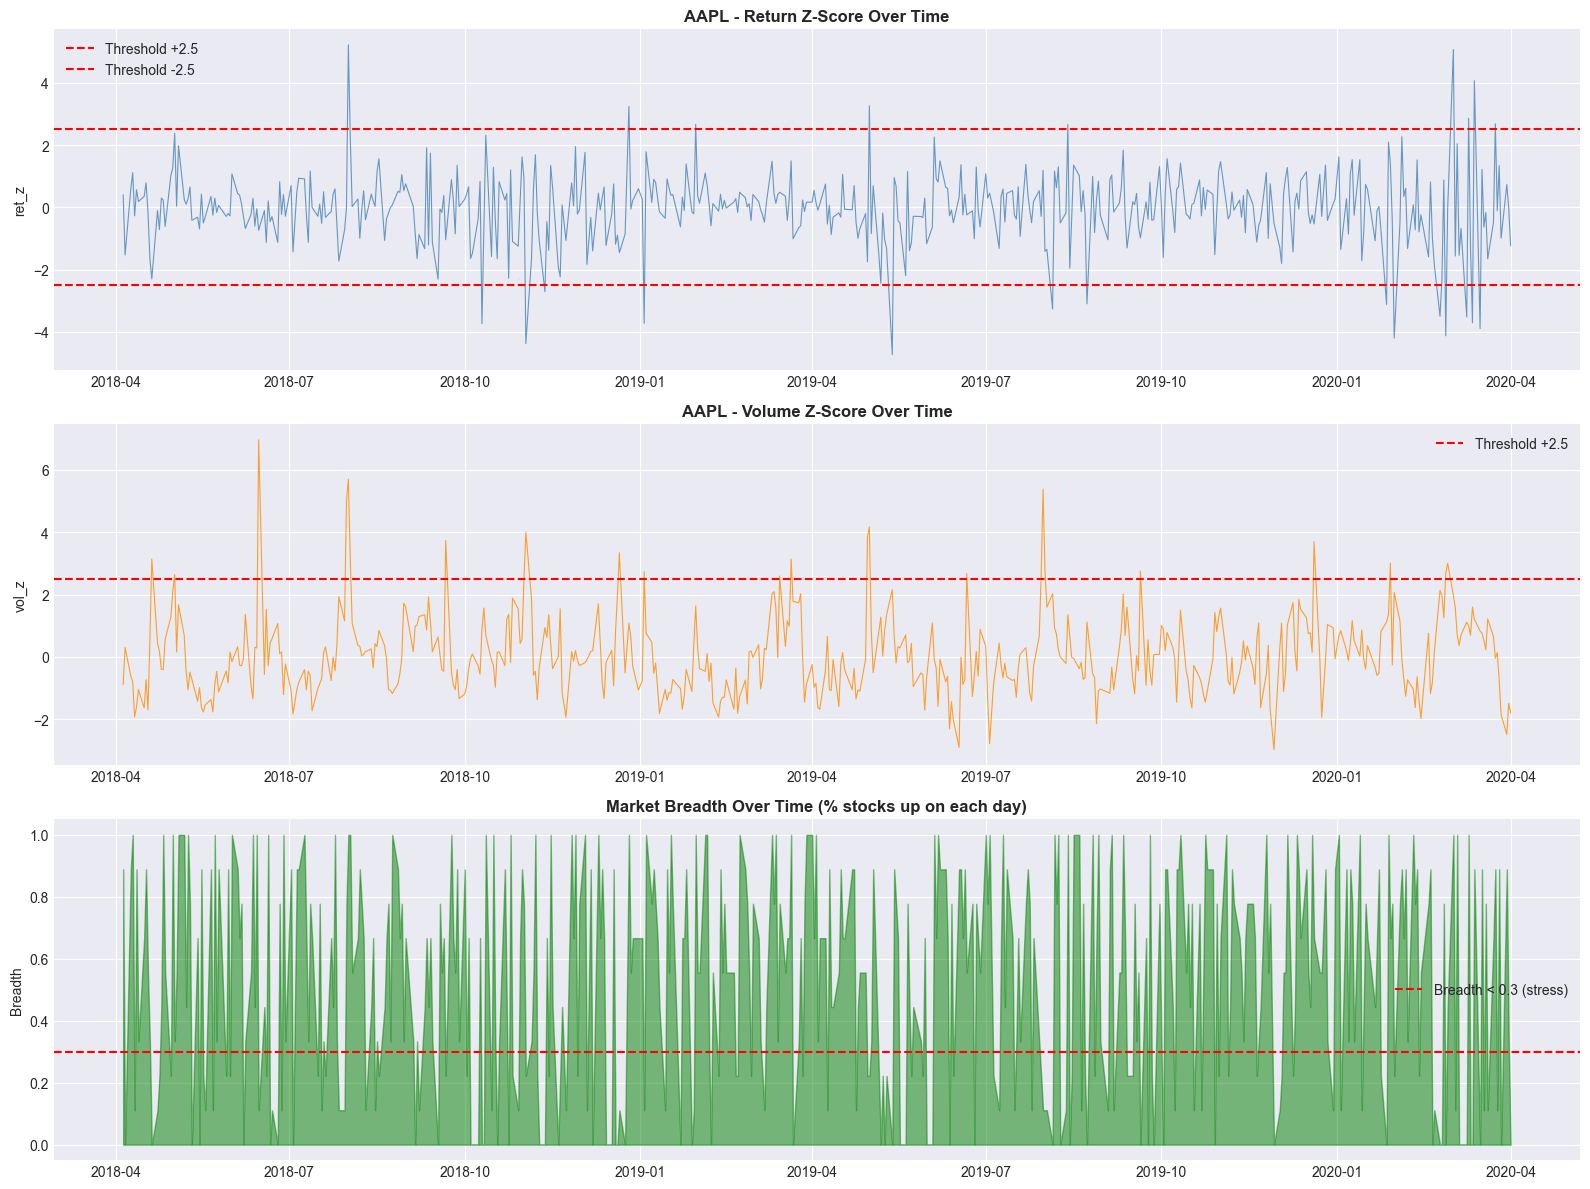

✅ Feature plots saved!


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: Return Z-scores over time for AAPL
aapl = featured[featured['Ticker'] == 'AAPL']
axes[0].plot(aapl['Date'], aapl['ret_z'], linewidth=0.8, alpha=0.8, color='steelblue')
axes[0].axhline(2.5, color='red', linestyle='--', label='Threshold +2.5')
axes[0].axhline(-2.5, color='red', linestyle='--', label='Threshold -2.5')
axes[0].set_title('AAPL - Return Z-Score Over Time', fontweight='bold')
axes[0].set_ylabel('ret_z')
axes[0].legend()

# Plot 2: Volume Z-scores
axes[1].plot(aapl['Date'], aapl['vol_z'], linewidth=0.8, alpha=0.8, color='darkorange')
axes[1].axhline(2.5, color='red', linestyle='--', label='Threshold +2.5')
axes[1].set_title('AAPL - Volume Z-Score Over Time', fontweight='bold')
axes[1].set_ylabel('vol_z')
axes[1].legend()

# Plot 3: Market breadth
axes[2].fill_between(market['Date'], market['breadth'], alpha=0.5, color='green')
axes[2].axhline(0.3, color='red', linestyle='--', label='Breadth < 0.3 (stress)')
axes[2].set_title('Market Breadth Over Time (% stocks up on each day)', fontweight='bold')
axes[2].set_ylabel('Breadth')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/plots/04_features_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature plots saved!")

 Save Featured Data

In [12]:
# Train / Val / Test split
train = featured[featured['Date'] <= '2018-12-31']
val   = featured[(featured['Date'] >= '2019-01-01') & (featured['Date'] <= '2019-12-31')]
test  = featured[featured['Date'] >= '2020-01-01']

train.to_csv('../data/processed/train.csv', index=False)
val.to_csv('../data/processed/val.csv', index=False)
test.to_csv('../data/processed/test.csv', index=False)
featured.to_csv('../data/processed/featured.csv', index=False)
market.to_csv('../data/processed/market_features.csv', index=False)

print(f"✅ All splits saved!")
print(f"Train : {train.shape} | {train['Date'].min().date()} → {train['Date'].max().date()}")
print(f"Val   : {val.shape}   | {val['Date'].min().date()} → {val['Date'].max().date()}")
print(f"Test  : {test.shape}  | {test['Date'].min().date()} → {test['Date'].max().date()}")

✅ All splits saved!
Train : (1683, 21) | 2018-04-05 → 2018-12-31
Val   : (2268, 21)   | 2019-01-02 → 2019-12-31
Test  : (567, 21)  | 2020-01-02 → 2020-04-01
